# Simple Convolutional Neural Network to Perform Classification

### EN3150 Pattern Recognition
##### Team Intellivawe - Brain Tumor MRI Dataset

### Imports

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

data_dir = "archive" # Directory containing the dataset ,please change this to your dataset directory
IMG_SIZE = 64
BATCH_SIZE = 32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(data_dir, transform=transform)
total_size = len(dataset)
train_size = int(0.70 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Classes:", dataset.classes)
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))
print(f"Ratios: {round(len(train_dataset)/total_size * 100)}% / "
      f"{round(len(val_dataset)/total_size * 100)}% / {round(len(test_dataset)/total_size * 100)}%")



Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train: 5040
Validation: 1080
Test: 1080
Ratios: 70% / 15% / 15%


### CNN A

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BrainTumorCNN_A(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3)
        self.pool1 = nn.MaxPool2d(2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.pool2 = nn.MaxPool2d(2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3)
        self.pool3 = nn.MaxPool2d(2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 6 * 6, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = self.pool3(F.relu(self.conv3(x)))

        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

model_A = BrainTumorCNN_A(num_classes=len(dataset.classes)).to(device)

print(model_A)

BrainTumorCNN_A(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=4608, out_features=128, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)


In [4]:
from torchinfo import summary

summary(
    model_A,
    input_size=(1, 3, 64, 64)
)

Layer (type:depth-idx)                   Output Shape              Param #
BrainTumorCNN_A                          [1, 4]                    --
├─Conv2d: 1-1                            [1, 32, 62, 62]           896
├─MaxPool2d: 1-2                         [1, 32, 31, 31]           --
├─Conv2d: 1-3                            [1, 64, 29, 29]           18,496
├─MaxPool2d: 1-4                         [1, 64, 14, 14]           --
├─Conv2d: 1-5                            [1, 128, 12, 12]          73,856
├─MaxPool2d: 1-6                         [1, 128, 6, 6]            --
├─Flatten: 1-7                           [1, 4608]                 --
├─Linear: 1-8                            [1, 128]                  589,952
├─Dropout: 1-9                           [1, 128]                  --
├─Linear: 1-10                           [1, 4]                    516
Total params: 683,716
Trainable params: 683,716
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 30.23
Input size (MB): 0.05
Forwa

### CNN B

In [5]:
import torch
import torch.nn as nn

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        # Depthwise Conv + BatchNorm + ReLU
        self.depthwise = nn.Conv2d(
            in_channels, in_channels,
            kernel_size=3, padding=1,
            groups=in_channels, bias=False
        )
        self.bn_dw = nn.BatchNorm2d(in_channels)
        self.relu_dw = nn.ReLU(inplace=True)

        # Pointwise Conv + BatchNorm + ReLU
        self.pointwise = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=1, bias=False
        )
        self.bn_pw = nn.BatchNorm2d(out_channels)
        self.relu_pw = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.relu_dw(self.bn_dw(self.depthwise(x)))
        x = self.relu_pw(self.bn_pw(self.pointwise(x)))
        return x


class ModelB(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        # Scaled channel progression: 3 -> 32 -> 64 -> 128 -> 192
        self.features = nn.Sequential(
            DepthwiseSeparableConv(3, 32),
            nn.MaxPool2d(2),

            DepthwiseSeparableConv(32, 64),
            nn.MaxPool2d(2),

            DepthwiseSeparableConv(64, 128),
            nn.MaxPool2d(2),

            DepthwiseSeparableConv(128, 192),
            nn.AdaptiveAvgPool2d(1)
        )

        # Direct classifier mapping from 192 features to num_classes
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(192),
            nn.Dropout(0.2),
            nn.Linear(192, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model_B = ModelB(num_classes=4)
print(f"Total Trainable Parameters: {count_trainable_params(model_B):,}")

Total Trainable Parameters: 39,397


In [36]:
from torchinfo import summary
summary(model_B, input_size=(1, 3, 64, 64))


Layer (type:depth-idx)                   Output Shape              Param #
ModelB                                   [1, 4]                    --
├─Sequential: 1-1                        [1, 192, 1, 1]            --
│    └─DepthwiseSeparableConv: 2-1       [1, 32, 64, 64]           --
│    │    └─Conv2d: 3-1                  [1, 3, 64, 64]            27
│    │    └─BatchNorm2d: 3-2             [1, 3, 64, 64]            6
│    │    └─ReLU: 3-3                    [1, 3, 64, 64]            --
│    │    └─Conv2d: 3-4                  [1, 32, 64, 64]           96
│    │    └─BatchNorm2d: 3-5             [1, 32, 64, 64]           64
│    │    └─ReLU: 3-6                    [1, 32, 64, 64]           --
│    └─MaxPool2d: 2-2                    [1, 32, 32, 32]           --
│    └─DepthwiseSeparableConv: 2-3       [1, 64, 32, 32]           --
│    │    └─Conv2d: 3-7                  [1, 32, 32, 32]           288
│    │    └─BatchNorm2d: 3-8             [1, 32, 32, 32]           64
│    │    └─ReL

In [6]:
print(f"\nModel B trainable parameters: {count_trainable_params(model_B):,}")


Model B trainable parameters: 39,397


### Training the Models

In [8]:
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

criterion = nn.CrossEntropyLoss()

def train_model(model, train_loader, val_loader, optimizer, epochs=20,
                 patience=5, monitor='val_acc', min_delta=0.0):
    """
    monitor: 'val_acc' (higher is better) or 'val_loss' (lower is better)
    patience: number of CONSECUTIVE epochs of degradation (vs. the previous
              epoch) allowed before stopping
    min_delta: minimum change to count as "improved" / "declined"
    """
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    epoch_times = []

    # Best-ever model tracking (independent of the stopping rule)
    best_metric = -float('inf') if monitor == 'val_acc' else float('inf')
    best_epoch = 0
    best_model_state = copy.deepcopy(model.state_dict())

    # Consecutive-decline tracking (compares to the previous epoch, not the best)
    prev_metric = None
    consecutive_decline = 0

    for epoch in range(epochs):
        start_time = time.time()

        model.train()
        running_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100.0 * train_correct / train_total

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100.0 * val_correct / val_total
        epoch_time = time.time() - start_time

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        epoch_times.append(epoch_time)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% "
            f"Time: {epoch_time:.2f}s"
        )

        current_metric = val_acc if monitor == 'val_acc' else val_loss

        # --- Track the best-ever model seen so far ---
        is_best = (
            current_metric > best_metric + min_delta if monitor == 'val_acc'
            else current_metric < best_metric - min_delta
        )
        if is_best:
            best_metric = current_metric
            best_epoch = epoch
            best_model_state = copy.deepcopy(model.state_dict())

        # --- Consecutive-decline stopping rule (vs. previous epoch) ---
        if prev_metric is not None:
            declined = (
                current_metric < prev_metric - min_delta if monitor == 'val_acc'
                else current_metric > prev_metric + min_delta
            )
            if declined:
                consecutive_decline += 1
                print(f"  Degraded for {consecutive_decline}/{patience} epoch(s) in a row")
            else:
                consecutive_decline = 0

        prev_metric = current_metric

        if consecutive_decline >= patience:
            print(f"\nStopping: {monitor} degraded for {patience} consecutive epochs. "
                  f"Best {monitor}: {best_metric:.4f} at epoch {best_epoch+1}.")
            break

    # Restore the best weights seen during training, not the last (possibly degraded) ones
    model.load_state_dict(best_model_state)
    print(f"Restored best model from epoch {best_epoch+1} "
          f"({monitor} = {best_metric:.4f})")

    return train_losses, val_losses, epoch_times

Train Model A

In [9]:
model_A = BrainTumorCNN_A(num_classes=len(dataset.classes)).to(device)

optimizer_A = optim.Adam(
    model_A.parameters(),
    lr=0.001
)

train_loss_A, val_loss_A, time_A = train_model(
    model_A,
    train_loader,
    val_loader,
    optimizer_A,
    epochs=20
)

Epoch [1/20] Train Loss: 0.9020 | Train Acc: 63.21% Val Loss: 0.8085 | Val Acc: 67.87% Time: 49.64s
Epoch [2/20] Train Loss: 0.6041 | Train Acc: 77.44% Val Loss: 0.5542 | Val Acc: 79.26% Time: 15.08s
Epoch [3/20] Train Loss: 0.4772 | Train Acc: 82.24% Val Loss: 0.4860 | Val Acc: 80.19% Time: 13.72s
Epoch [4/20] Train Loss: 0.4007 | Train Acc: 85.18% Val Loss: 0.4155 | Val Acc: 85.28% Time: 13.23s
Epoch [5/20] Train Loss: 0.3280 | Train Acc: 88.10% Val Loss: 0.3996 | Val Acc: 84.91% Time: 13.24s
Epoch [6/20] Train Loss: 0.2710 | Train Acc: 90.36% Val Loss: 0.3561 | Val Acc: 87.78% Time: 12.92s
Epoch [7/20] Train Loss: 0.2148 | Train Acc: 92.00% Val Loss: 0.3823 | Val Acc: 85.65% Time: 15.83s
Epoch [8/20] Train Loss: 0.1858 | Train Acc: 93.27% Val Loss: 0.2972 | Val Acc: 91.39% Time: 15.00s
Epoch [9/20] Train Loss: 0.1497 | Train Acc: 94.21% Val Loss: 0.2663 | Val Acc: 92.41% Time: 13.28s
Epoch [10/20] Train Loss: 0.1221 | Train Acc: 95.65% Val Loss: 0.2794 | Val Acc: 92.41% Time: 13.39s

Train Model B

In [37]:
modelB = ModelB(num_classes=len(dataset.classes)).to(device)

optimizer_B = optim.Adam(
    modelB.parameters(),
    lr=0.001
)

train_loss_B, val_loss_B, time_B = train_model(
    modelB,
    train_loader,
    val_loader,
    optimizer_B,
    epochs=20
)

Epoch [1/20] Train Loss: 0.6971 | Train Acc: 73.63% Val Loss: 0.6860 | Val Acc: 78.52% Time: 14.64s
Epoch [2/20] Train Loss: 0.4099 | Train Acc: 85.93% Val Loss: 1.1198 | Val Acc: 68.43% Time: 15.14s
Epoch [3/20] Train Loss: 0.3192 | Train Acc: 88.47% Val Loss: 0.3605 | Val Acc: 85.46% Time: 14.09s
Epoch [4/20] Train Loss: 0.2345 | Train Acc: 91.65% Val Loss: 0.5375 | Val Acc: 84.26% Time: 14.77s
Epoch [5/20] Train Loss: 0.1677 | Train Acc: 94.64% Val Loss: 0.4034 | Val Acc: 85.65% Time: 14.79s
Epoch [6/20] Train Loss: 0.1385 | Train Acc: 95.42% Val Loss: 0.6991 | Val Acc: 79.44% Time: 14.05s
Epoch [7/20] Train Loss: 0.1047 | Train Acc: 96.59% Val Loss: 0.4149 | Val Acc: 86.76% Time: 14.14s
Epoch [8/20] Train Loss: 0.0849 | Train Acc: 96.92% Val Loss: 0.5071 | Val Acc: 83.43% Time: 13.52s
Epoch [9/20] Train Loss: 0.0828 | Train Acc: 97.26% Val Loss: 0.5877 | Val Acc: 85.37% Time: 14.54s
Epoch [10/20] Train Loss: 0.0778 | Train Acc: 97.40% Val Loss: 0.5905 | Val Acc: 83.06% Time: 14.64s

Plot loss curves

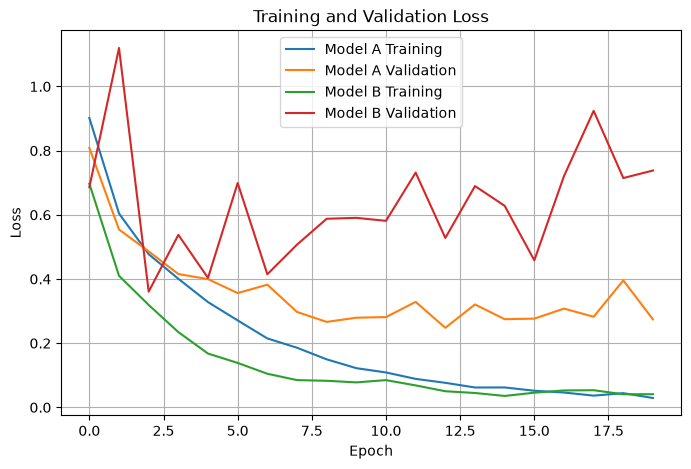

In [38]:
plt.figure(figsize=(8, 5))

plt.plot(train_loss_A, label="Model A Training")
plt.plot(val_loss_A, label="Model A Validation")
plt.plot(train_loss_B, label="Model B Training")
plt.plot(val_loss_B, label="Model B Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

Test evaluation

In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def evaluate_model(model, test_loader):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            outputs = model(images)
            predictions = torch.argmax(outputs, dim=1)

            y_true.extend(labels.numpy())
            y_pred.extend(predictions.cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(
        y_true, y_pred, average="weighted", zero_division=0
    )
    recall = recall_score(
        y_true, y_pred, average="weighted", zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred)

    return accuracy, precision, recall, cm

In [13]:
acc_A, precision_A, recall_A, cm_A = evaluate_model(
    model_A, test_loader
)

acc_B, precision_B, recall_B, cm_B = evaluate_model(
    modelB, test_loader
)

print("Model A")
print("Accuracy :", acc_A)
print("Precision:", precision_A)
print("Recall   :", recall_A)


print("\nModel B")
print("Accuracy :", acc_B)
print("Precision:", precision_B)
print("Recall   :", recall_B)


Model A
Accuracy : 0.9527777777777777
Precision: 0.9525461195881851
Recall   : 0.9527777777777777

Model B
Accuracy : 0.8166666666666667
Precision: 0.8216924521425832
Recall   : 0.8166666666666667


Confusion matrices

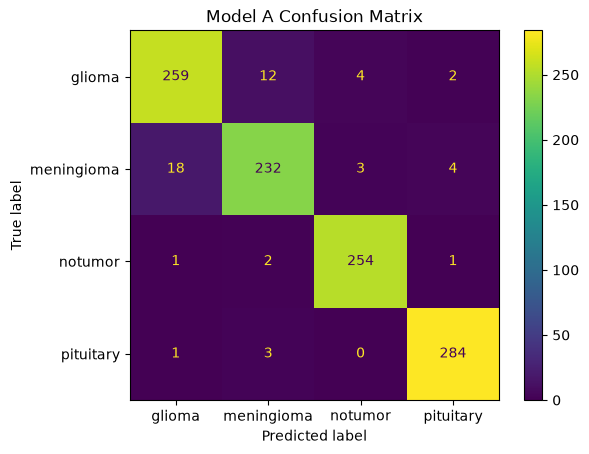

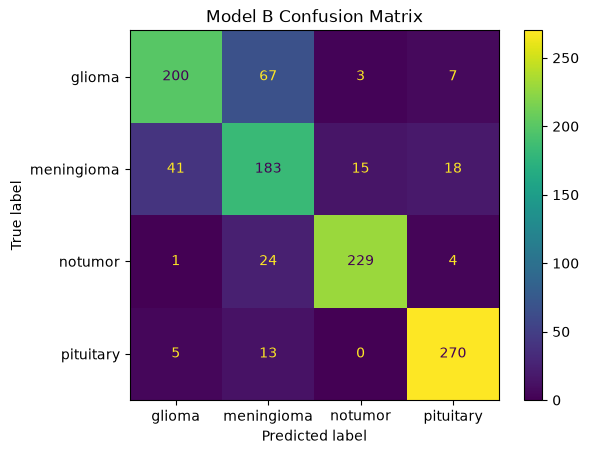

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    cm_A,
    display_labels=dataset.classes
).plot()

plt.title("Model A Confusion Matrix")
plt.show()

ConfusionMatrixDisplay(
    cm_B,
    display_labels=dataset.classes
).plot()

plt.title("Model B Confusion Matrix")
plt.show()

Model comparison table

In [41]:
params_A = sum(p.numel() for p in model_A.parameters() if p.requires_grad)
params_B = sum(p.numel() for p in modelB.parameters() if p.requires_grad)

print("Model A parameters:", params_A)
print("Model B parameters:", params_B)

print("Model A average epoch time:", sum(time_A) / len(time_A), "seconds")
print("Model B average epoch time:", sum(time_B) / len(time_B), "seconds")

Model A parameters: 683716
Model B parameters: 39397
Model A average epoch time: 15.776743185520171 seconds
Model B average epoch time: 13.94935691356659 seconds


Model A achieved a test accuracy of 95.27, while Model B achieved 81.67%. Although Model B significantly reduces the number of trainable parameters and computational complexity through depthwise separable convolutions, this reduction in model complexity resulted in lower classification performance on the test dataset. This demonstrates the trade-off between computational efficiency and classification accuracy.

### Compare Adam, SGD and SGD + Momentum

Model A + Adam

Model A + SGD

Model A + SGD with Momentum

In [16]:
# Adam
model_adam = BrainTumorCNN_A(num_classes=len(dataset.classes)).to(device)
optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.001)

# SGD
model_sgd = BrainTumorCNN_A(num_classes=len(dataset.classes)).to(device)
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.01)

# SGD + Momentum
model_momentum = BrainTumorCNN_A(num_classes=len(dataset.classes)).to(device)
optimizer_momentum = optim.SGD(
    model_momentum.parameters(),
    lr=0.01,
    momentum=0.9
)

In [18]:
train_sgd, val_sgd, time_sgd = train_model(
    model_sgd, train_loader, val_loader,
    optimizer_sgd, epochs=20
)

train_momentum, val_momentum, time_momentum = train_model(
    model_momentum, train_loader, val_loader,
    optimizer_momentum, epochs=20
)

Epoch [1/20] Train Loss: 1.3817 | Train Acc: 29.46% Val Loss: 1.3777 | Val Acc: 24.44% Time: 15.89s
Epoch [2/20] Train Loss: 1.3643 | Train Acc: 25.63% Val Loss: 1.3565 | Val Acc: 24.44% Time: 15.87s
Epoch [3/20] Train Loss: 1.3215 | Train Acc: 30.95% Val Loss: 1.2794 | Val Acc: 52.13% Time: 15.16s
Epoch [4/20] Train Loss: 1.1762 | Train Acc: 56.61% Val Loss: 1.1018 | Val Acc: 60.93% Time: 14.19s
Epoch [5/20] Train Loss: 1.0305 | Train Acc: 61.63% Val Loss: 0.9635 | Val Acc: 68.06% Time: 14.13s
Epoch [6/20] Train Loss: 0.9466 | Train Acc: 64.62% Val Loss: 1.0858 | Val Acc: 54.72% Time: 14.47s
Epoch [7/20] Train Loss: 0.8916 | Train Acc: 67.44% Val Loss: 0.9150 | Val Acc: 68.33% Time: 14.17s
Epoch [8/20] Train Loss: 0.8324 | Train Acc: 69.90% Val Loss: 0.8464 | Val Acc: 65.83% Time: 14.13s
Epoch [9/20] Train Loss: 0.7958 | Train Acc: 70.10% Val Loss: 0.7859 | Val Acc: 71.30% Time: 14.15s
Epoch [10/20] Train Loss: 0.7460 | Train Acc: 73.02% Val Loss: 0.7358 | Val Acc: 72.13% Time: 14.31s

Compare the results

In [19]:
for name, model in [
    ("Adam", model_A),
    ("SGD", model_sgd),
    ("SGD + Momentum", model_momentum)
]:
    acc, precision, recall, cm = evaluate_model(model, test_loader)

    print(f"\n{name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")


Adam
Accuracy : 0.9528
Precision: 0.9525
Recall   : 0.9528

SGD
Accuracy : 0.8463
Precision: 0.8477
Recall   : 0.8463

SGD + Momentum
Accuracy : 0.9343
Precision: 0.9346
Recall   : 0.9343


Three optimizers, Adam, SGD, and SGD with Momentum, were compared using the same CNN architecture and 20 training epochs. Adam achieved 95.28% accuracy, while standard SGD achieved 84.63%. SGD with Momentum achieved the highest accuracy of 93.43%. This shows that momentum helped improve convergence and classification performance compared with standard SGD.


### Traning the model B with SGD and SGD with momentum

In [9]:
# SGD
model_sgd_B =  ModelB(num_classes=len(dataset.classes)).to(device)
optimizer_sgd_B = optim.SGD(model_sgd_B.parameters(), lr=0.01)

# SGD + Momentum
model_momentum_B = ModelB(num_classes=len(dataset.classes)).to(device)
optimizer_momentum_B = optim.SGD(
    model_momentum_B.parameters(),
    lr=0.01,
    momentum=0.9
)

train_sgd_B, val_sgd_B, time_sgd_B = train_model(
    model_sgd_B, train_loader, val_loader,
    optimizer_sgd_B, epochs=20
)



Epoch [1/20] Train Loss: 0.8333 | Train Acc: 67.34% Val Loss: 1.1899 | Val Acc: 57.22% Time: 14.81s
Epoch [2/20] Train Loss: 0.6402 | Train Acc: 75.73% Val Loss: 0.5839 | Val Acc: 78.70% Time: 12.83s
Epoch [3/20] Train Loss: 0.5438 | Train Acc: 80.34% Val Loss: 0.6918 | Val Acc: 72.69% Time: 13.71s
  Degraded for 1/5 epoch(s) in a row
Epoch [4/20] Train Loss: 0.4745 | Train Acc: 82.18% Val Loss: 0.5632 | Val Acc: 77.22% Time: 15.18s
Epoch [5/20] Train Loss: 0.4178 | Train Acc: 84.86% Val Loss: 0.6951 | Val Acc: 73.43% Time: 13.52s
  Degraded for 1/5 epoch(s) in a row
Epoch [6/20] Train Loss: 0.3927 | Train Acc: 86.41% Val Loss: 0.4952 | Val Acc: 81.02% Time: 13.83s
Epoch [7/20] Train Loss: 0.3265 | Train Acc: 88.35% Val Loss: 0.7151 | Val Acc: 75.37% Time: 13.26s
  Degraded for 1/5 epoch(s) in a row
Epoch [8/20] Train Loss: 0.3125 | Train Acc: 88.47% Val Loss: 0.4253 | Val Acc: 83.24% Time: 12.70s
Epoch [9/20] Train Loss: 0.2747 | Train Acc: 89.74% Val Loss: 0.4126 | Val Acc: 84.44% Ti

In [10]:
train_momentum_B, val_momentum_B, time_momentum_B = train_model(
    model_momentum_B, train_loader, val_loader,
    optimizer_momentum_B, epochs=20
)

Epoch [1/20] Train Loss: 0.7567 | Train Acc: 71.67% Val Loss: 0.6928 | Val Acc: 72.78% Time: 14.91s
Epoch [2/20] Train Loss: 0.5160 | Train Acc: 81.49% Val Loss: 0.7434 | Val Acc: 72.87% Time: 14.39s
Epoch [3/20] Train Loss: 0.4095 | Train Acc: 84.90% Val Loss: 0.8279 | Val Acc: 75.56% Time: 14.92s
Epoch [4/20] Train Loss: 0.3374 | Train Acc: 88.04% Val Loss: 0.5284 | Val Acc: 82.41% Time: 14.08s
Epoch [5/20] Train Loss: 0.2729 | Train Acc: 90.65% Val Loss: 0.5470 | Val Acc: 83.52% Time: 14.11s
Epoch [6/20] Train Loss: 0.2515 | Train Acc: 91.03% Val Loss: 0.6994 | Val Acc: 78.24% Time: 15.06s
  Degraded for 1/5 epoch(s) in a row
Epoch [7/20] Train Loss: 0.2150 | Train Acc: 92.32% Val Loss: 0.7302 | Val Acc: 75.28% Time: 14.91s
  Degraded for 2/5 epoch(s) in a row
Epoch [8/20] Train Loss: 0.1592 | Train Acc: 94.21% Val Loss: 0.7436 | Val Acc: 80.46% Time: 14.07s
Epoch [9/20] Train Loss: 0.1566 | Train Acc: 94.46% Val Loss: 0.8859 | Val Acc: 78.89% Time: 14.94s
  Degraded for 1/5 epoch(s

In [13]:
for name, model in [
    #("Adam", modelB),
    ("SGD", model_sgd_B),
    ("SGD + Momentum", model_momentum_B)
]:
    acc, precision, recall, cm = evaluate_model(model, test_loader)

    print(f"\n{name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")


SGD
Accuracy : 0.8833
Precision: 0.8885
Recall   : 0.8833

SGD + Momentum
Accuracy : 0.9204
Precision: 0.9222
Recall   : 0.9204


## Section 2 -  Compare with Lightweight State-of-the-Art Networks

In [14]:
import torch.nn as nn
from torchvision import models

num_classes = len(dataset.classes)

# --- MobileNetV2 ---
mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
mobilenet.classifier[1] = nn.Linear(mobilenet.last_channel, num_classes)
mobilenet = mobilenet.to(device)

# --- SqueezeNet 1.1 ---
squeezenet = models.squeezenet1_1(weights=models.SqueezeNet1_1_Weights.IMAGENET1K_V1)
squeezenet.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=1)
squeezenet.num_classes = num_classes
squeezenet = squeezenet.to(device)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\ASUS TUF X506H/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [01:22<00:00, 173kB/s]


Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to C:\Users\ASUS TUF X506H/.cache\torch\hub\checkpoints\squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:33<00:00, 149kB/s]


In [15]:
import torch.optim as optim
import time

def train_model(model, train_loader, val_loader, epochs=10, lr=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        # validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {running_loss/len(train_loader.dataset):.4f} - Val Acc: {correct/total:.4f}")

    return model


def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = correct / total
    return acc, all_preds, all_labels

#### Training the models

In [16]:
mobilenet = train_model(mobilenet, train_loader, val_loader, epochs=10)
mobilenet_acc, mn_preds, mn_labels = evaluate_model(mobilenet, test_loader)

squeezenet = train_model(squeezenet, train_loader, val_loader, epochs=10)
sq_acc, sq_preds, sq_labels = evaluate_model(squeezenet, test_loader)

print(f"MobileNetV2 Test Accuracy: {mobilenet_acc:.4f}")
print(f"SqueezeNet Test Accuracy: {sq_acc:.4f}")

Epoch 1/10 - Train Loss: 0.5249 - Val Acc: 0.9000
Epoch 2/10 - Train Loss: 0.2252 - Val Acc: 0.9398
Epoch 3/10 - Train Loss: 0.1342 - Val Acc: 0.9370
Epoch 4/10 - Train Loss: 0.0849 - Val Acc: 0.9278
Epoch 5/10 - Train Loss: 0.0646 - Val Acc: 0.9454
Epoch 6/10 - Train Loss: 0.0560 - Val Acc: 0.9361
Epoch 7/10 - Train Loss: 0.0541 - Val Acc: 0.9537
Epoch 8/10 - Train Loss: 0.0433 - Val Acc: 0.9593
Epoch 9/10 - Train Loss: 0.0300 - Val Acc: 0.9509
Epoch 10/10 - Train Loss: 0.0365 - Val Acc: 0.9491
Epoch 1/10 - Train Loss: 1.0385 - Val Acc: 0.7426
Epoch 2/10 - Train Loss: 0.5597 - Val Acc: 0.8333
Epoch 3/10 - Train Loss: 0.4271 - Val Acc: 0.8648
Epoch 4/10 - Train Loss: 0.3364 - Val Acc: 0.8926
Epoch 5/10 - Train Loss: 0.2928 - Val Acc: 0.8861
Epoch 6/10 - Train Loss: 0.2482 - Val Acc: 0.9120
Epoch 7/10 - Train Loss: 0.2160 - Val Acc: 0.8639
Epoch 8/10 - Train Loss: 0.2127 - Val Acc: 0.9157
Epoch 9/10 - Train Loss: 0.1651 - Val Acc: 0.9287
Epoch 10/10 - Train Loss: 0.1464 - Val Acc: 0.932

In [18]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(labels, preds, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(labels, preds)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=class_names,
           yticklabels=class_names,
           ylabel='True label',
           xlabel='Predicted label',
           title=title)
    
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
    
    # annotate each cell with the count
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    
    fig.tight_layout()
    plt.show()

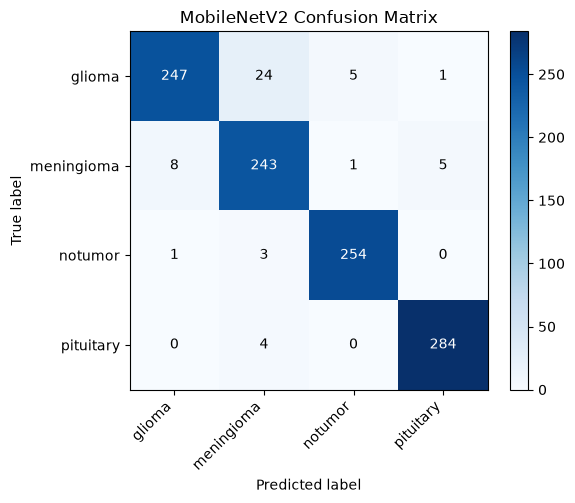

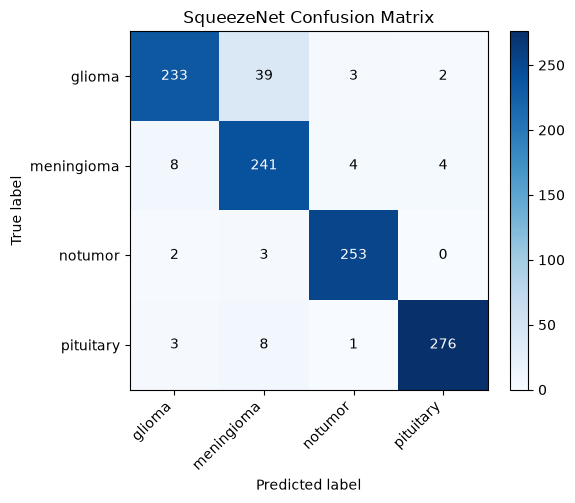

In [19]:
plot_confusion_matrix(mn_labels, mn_preds, dataset.classes, title="MobileNetV2 Confusion Matrix")
plot_confusion_matrix(sq_labels, sq_preds, dataset.classes, title="SqueezeNet Confusion Matrix")

Model Size and Parameter counts

In [17]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def model_size_mb(model):
    torch.save(model.state_dict(), "temp.pth")
    size_mb = os.path.getsize("temp.pth") / (1024 ** 2)
    os.remove("temp.pth")
    return size_mb

import os
for name, model in [("MobileNetV2", mobilenet), ("SqueezeNet1.1", squeezenet)]:
    total, trainable = count_params(model)
    size = model_size_mb(model)
    print(f"{name}: {total:,} params ({trainable:,} trainable), {size:.2f} MB")

MobileNetV2: 2,228,996 params (2,228,996 trainable), 8.72 MB
SqueezeNet1.1: 724,548 params (724,548 trainable), 2.78 MB
